<a href="https://colab.research.google.com/github/KiranKokateGitHub/Bank-Marketing-Effectiveness-Prediction_Classification/blob/main/netflix_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **About the database**

Introduction This database, which contains information about Netflix movies and series, has 12 columns, including some null values. The analysis was carried out with the Pandas, Matplotlib and Seaborn libraries, which were used to treat, process and visualize the information.




In [3]:
# import requirmenmts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
from google.colab import files
uploaded = files.upload()   # Upload netflix_movies (1).csv

Saving netflix_movies (1).csv to netflix_movies (1).csv


In [6]:
df_net = pd.read_csv('netflix_movies (1).csv')

In [7]:
df_net.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2576,s2577,Movie,All Day and a Night,Joe Robert Cole,"Jeffrey Wright, Ashton Sanders, Regina Taylor,...",United States,"May 1, 2020",2020,R,122 min,"Dramas, Independent Movies","While serving life in prison, a young man look..."
8587,s8588,Movie,Thunderbolt,"William Wyler, John Sturges","James Stewart, Lloyd Bridges",United States,"March 31, 2017",1947,TV-PG,42 min,"Classic Movies, Documentaries",A P-47 Thunderbolt squadron is shown in prepar...
5851,s5852,Movie,Belgica,"Felix Van Groeningen, Felix van Groeningen","Stef Aerts, Tom Vermeir, Charlotte Vandermeers...","Belgium, France, Netherlands","April 15, 2016",2016,TV-MA,127 min,"Dramas, International Movies",Two brothers become partners in a modest night...
1653,s1654,Movie,Andhakaaram,V Vignarajan,"Vinoth Kishan, Arjun Das, Pooja Ramachandran, ...",India,"November 24, 2020",2020,TV-14,171 min,"Horror Movies, International Movies, Thrillers","As a blind librarian, dispirited cricketer and..."
883,s884,TV Show,"Love, Death & Robots",NaN,"Topher Grace, Mary Elizabeth Winstead, Gary Co...",United States,"May 14, 2021",2021,TV-MA,2 Seasons,"TV Action & Adventure, TV Horror, TV Sci-Fi & ...","Terrifying creatures, wicked surprises and dar..."


In [8]:
df_net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df_net.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
df_net.describe(include = 'object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Feb-09,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,3207,1793,362,4


In [11]:
df_net.shape

(8807, 12)

In [12]:
df_net.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [13]:
df_net.duplicated().sum()

np.int64(0)

In [14]:
df_net['director'] = df_net['director'].fillna('Not Available')

In [15]:
df_net.dropna(inplace = True)

In [16]:
df_net.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# **Feature Engnieering**

Conversion of duration columns dtypes to datetime dtypes and spliting the year, month and date columns¶¶

In [17]:
df_net['date'] = pd.to_datetime(df_net['date_added'], errors='coerce')
df_net['day'] = df_net['date'].dt.day
df_net['month'] = df_net['date'].dt.month
df_net['year'] = df_net['date'].dt.year
df_net.drop(['date_added','date'],axis = 1,inplace = True)

In [18]:
df_net.sample(5)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
7975,s7976,Movie,Secrets of Scotland Yard,Susannah Ward,Samuel West,United Kingdom,2013,TV-14,55 min,Documentaries,Revisit famous cases and explore the history o...,22.0,4.0,2017.0
1710,s1711,Movie,Fruitvale Station,Ryan Coogler,"Michael B. Jordan, Melonie Diaz, Octavia Spenc...",United States,2013,R,85 min,"Dramas, Independent Movies",This dramatic rendering of a real-life tragedy...,12.0,11.0,2020.0
6606,s6607,Movie,Diana: 7 Days That Shook the World,Ben Ryder,James D'Arcy,United Kingdom,2017,TV-PG,93 min,Documentaries,This illuminating documentary examines the aft...,28.0,7.0,2017.0
1396,s1397,Movie,Homefront,Gary Fleder,"Jason Statham, James Franco, Izabela Vidovic, ...",United States,2013,R,100 min,Action & Adventure,"When an ex-DEA agent is widowed, he moves with...",18.0,1.0,2021.0
2048,s2049,Movie,The Lost Okoroshi,Abba T. Makama,"Seun Ajayi, Judith Audu, Tope Tedela, Ifu Enna...",Nigeria,2019,TV-MA,94 min,"Comedies, Dramas, Independent Movies",A disillusioned security guard transforms into...,4.0,9.0,2020.0


In [19]:
df_net.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
release_year,0
rating,0
duration,0
listed_in,0


In [20]:
df_net.dropna(inplace = True)

In [21]:
df_net.sample(10)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
8020,s8021,TV Show,Silver Spoon,Not Available,"Pavel Priluchnyy, Karina Razumovskaya, Dmitry ...",Russia,2015,TV-MA,2 Seasons,"Crime TV Shows, International TV Shows, TV Act...","Forced to become an apprentice cop, cocky play...",15.0,9.0,2017.0
3634,s3635,Movie,The Red Sea Diving Resort,Gideon Raff,"Chris Evans, Michael Kenneth Williams, Haley B...",Canada,2019,TV-MA,130 min,"Dramas, Thrillers",Undercover agents open up a fake hotel to real...,31.0,7.0,2019.0
3563,s3564,Movie,Kaake Da Viyah,Rai Yuvraj Bains,"Priti Sapru, Nirmal Rishi, Jordan Sandhu, Prab...",India,2019,TV-PG,133 min,"Comedies, Dramas, International Movies","In this zany comedy, a man is torn between the...",23.0,8.0,2019.0
1772,s1773,Movie,The 12th Man,Harald Zwart,"Thomas Gullestad, Jonathan Rhys Meyers, Marie ...",Norway,2018,TV-MA,130 min,"Action & Adventure, Dramas, International Movies","Based on true events, this story follows a Nor...",31.0,10.0,2020.0
1513,s1514,Movie,Atlas Shrugged: Part II,John Putch,"Samantha Mathis, Jason Beghe, Esai Morales, Pa...",United States,2012,PG-13,112 min,Dramas,"With the world's economy in dire straits, corp...",19.0,12.0,2020.0
7620,s7621,Movie,Now and Then,Lesli Linka Glatter,"Christina Ricci, Rosie O'Donnell, Thora Birch,...",United States,1995,PG-13,102 min,Dramas,Waxing nostalgic about the bittersweet passage...,2.0,8.0,2019.0
767,s768,TV Show,Creator's File: GOLD,Not Available,"Ryuji Akiyama, Ryusei Yokohama, Yumi Adachi, A...",Japan,2021,TV-14,1 Season,"International TV Shows, TV Comedies",Comedian Ryuji Akiyama satirizes top “creators...,3.0,6.0,2021.0
2196,s2197,Movie,Redemption,Mickey Fonseca,"Gil Alexandre, Arlete Bombe, Rashid Abdul, Laq...",Mozambique,2019,TV-MA,102 min,"Dramas, International Movies, Thrillers","Newly released from prison, a man returning to...",29.0,7.0,2020.0
2875,s2876,TV Show,Followers,Not Available,"Miki Nakatani, Elaiza Ikeda, Mari Natsuki, Yuk...",Japan,2020,TV-MA,1 Season,"International TV Shows, TV Dramas",When an aspiring actress hits it big thanks to...,27.0,2.0,2020.0
5933,s5934,TV Show,The Borgias,Not Available,"Jeremy Irons, François Arnaud, Holliday Graing...","United States, Hungary, Ireland, Canada",2013,TV-MA,3 Seasons,TV Dramas,Follow the lives of the notorious Borgia famil...,1.0,2.0,2014.0


# 2.Questions on Data¶
# 1.Univariate Data Visualization **bold text**

1.Which type of content is more prevalent on the platform: Movies or TV Shows

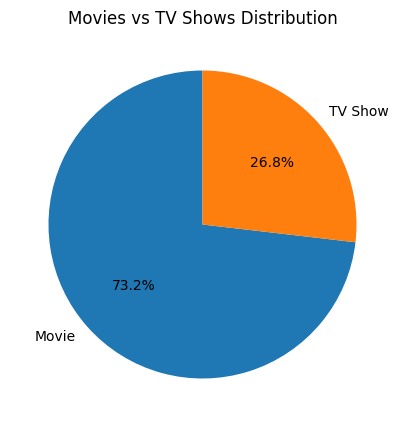

,count
type,
Movie,5277
TV Show,1936


In [22]:
plt.figure(figsize =(5,5))
type_counts = df_net['type'].value_counts()
plt.pie(type_counts,labels = type_counts.index,autopct='%1.1f%%', startangle=90)
plt.title('Movies vs TV Shows Distribution')
plt.show()

type_counts

2.Top 10 Directors by Number of Titles¶

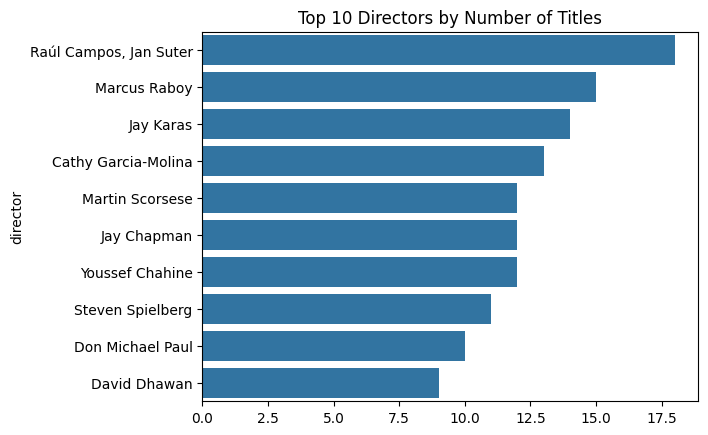

,count
director,
"Raúl Campos, Jan Suter",18
Marcus Raboy,15
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Jay Chapman,12
Youssef Chahine,12
Steven Spielberg,11
Don Michael Paul,10


In [23]:
df_net1 = df_net[df_net['director'] != 'Not Available']
top_directors = df_net1['director'].value_counts().head(10)
sns.barplot(y=top_directors.index, x=top_directors.values)
plt.title('Top 10 Directors by Number of Titles')
plt.show()
top_directors

3.Top 10 Cast Actresses and Actor

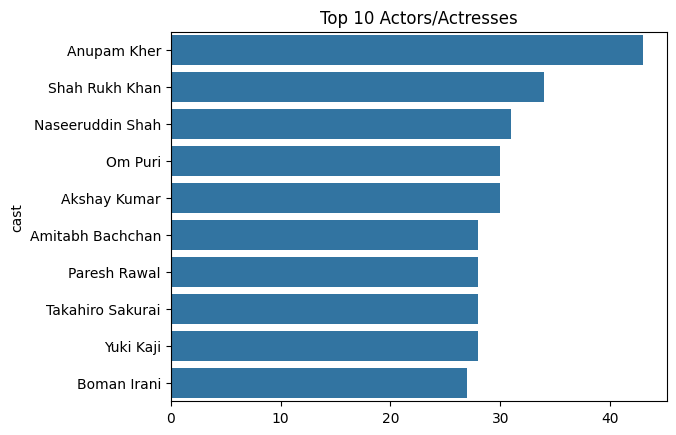

,count
cast,
Anupam Kher,43
Shah Rukh Khan,34
Naseeruddin Shah,31
Om Puri,30
Akshay Kumar,30
Amitabh Bachchan,28
Paresh Rawal,28
Takahiro Sakurai,28
Yuki Kaji,28


In [24]:

cast_members = df_net['cast'].str.split(', ').explode()
top_cast = cast_members.value_counts().head(10)
sns.barplot(y=top_cast.index, x=top_cast.values)
plt.title('Top 10 Actors/Actresses')
plt.show()
top_cast

4.Which countries produce the most content?

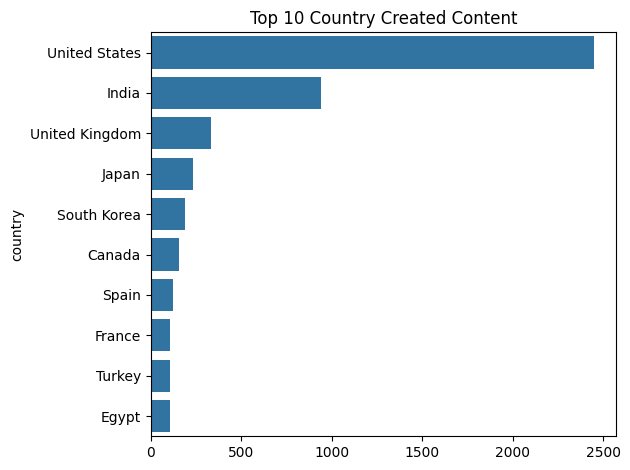

,count
country,
United States,2449
India,939
United Kingdom,335
Japan,236
South Korea,192
Canada,155
Spain,123
France,106
Turkey,105


In [25]:
top_country = df_net['country'].value_counts().head(10)
sns.barplot(y = top_country.index ,x = top_country.values )
plt.title('Top 10 Country Created Content')
plt.tight_layout()
plt.show()
top_country

5.How has the number of releases (release_year) for movies and TV shows evolved over the years?¶

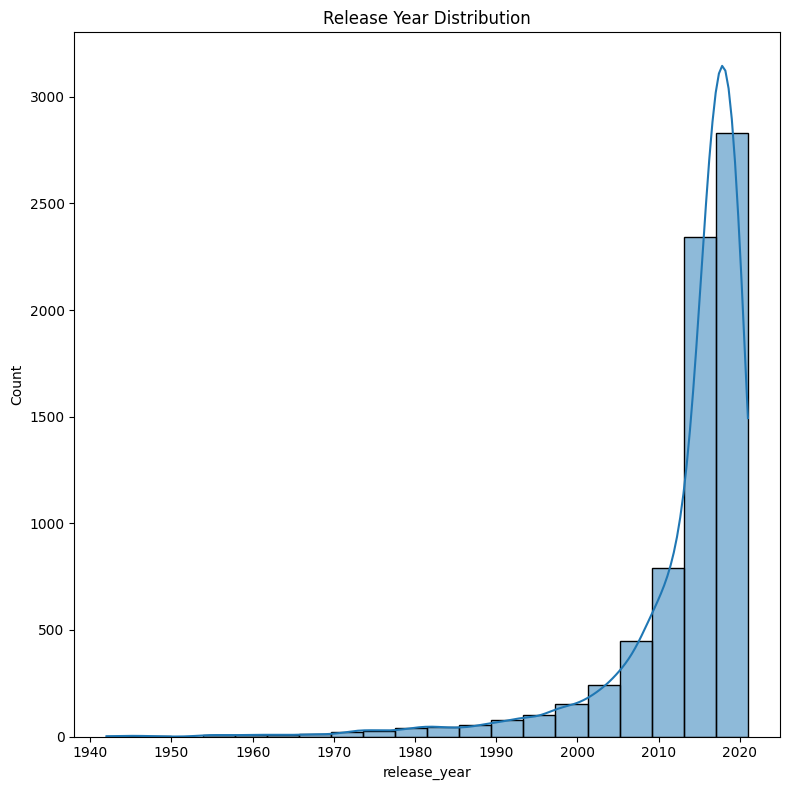

In [26]:
plt.figure(figsize =(8,8))
sns.histplot(df_net['release_year'], bins=20, kde=True)
plt.title('Release Year Distribution')
plt.tight_layout()
plt.show()

6.What are the most common ratings for movies and TV shows?¶

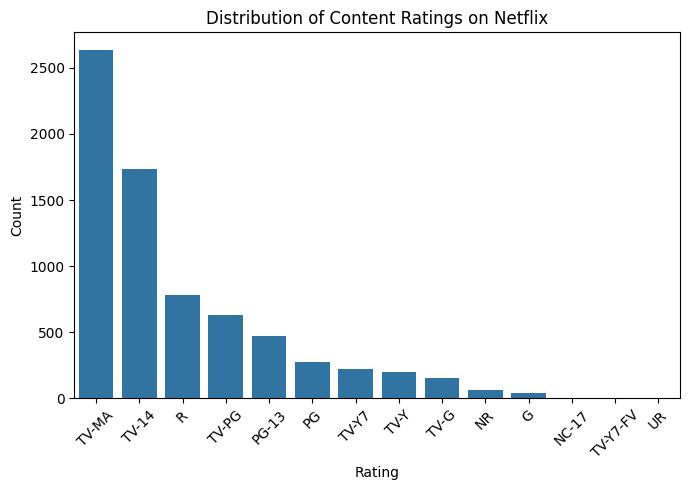

In [27]:
plt.figure(figsize=(7,5))

rating_order = df_net['rating'].value_counts().index
sns.countplot(x='rating', data=df_net , order = rating_order)
plt.xticks(rotation=45)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

 df_net['rating'].value_counts()

In [28]:
 df_net['rating'].value_counts()

,count
rating,
TV-MA,2636
TV-14,1734
R,779
TV-PG,633
PG-13,470
PG,275
TV-Y7,220
TV-Y,203
TV-G,153


7.What are the Most Genres in Netflix ?

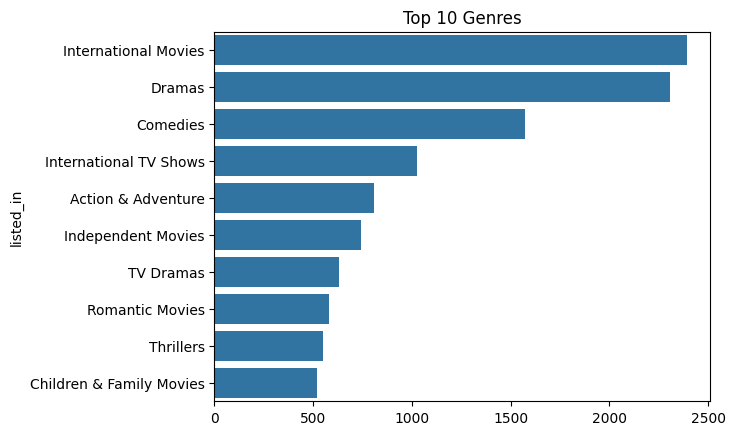

,count
listed_in,
International Movies,2392
Dramas,2309
Comedies,1574
International TV Shows,1027
Action & Adventure,811
Independent Movies,742
TV Dramas,634
Romantic Movies,583
Thrillers,549


In [29]:
genres = df_net['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
sns.barplot(y=top_genres.index, x=top_genres.values)
plt.title('Top 10 Genres')
plt.show()

top_genres

8.What is the average duration of movies?

In [30]:
movie_durations = df_net.loc[df_net['type'] == 'Movie']['duration'].str.replace(' min','').astype(float).reset_index(drop=True)

average_duration = movie_durations.mean()
print(f"Average movie duration: {average_duration:.2f} minutes")

Average movie duration: 102.14 minutes


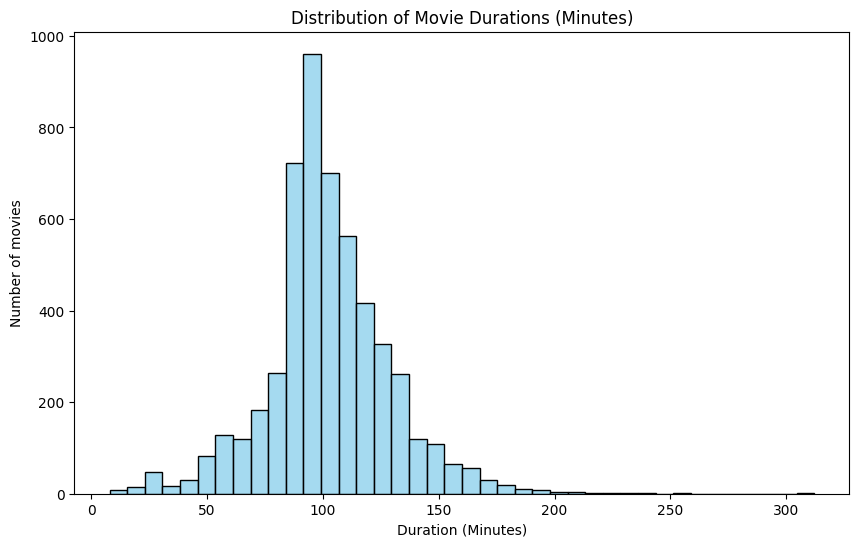

In [31]:
plt.figure(figsize=(10,6))

plt.title("Distribution of Movie Durations (Minutes)")

sns.histplot(movie_durations, bins=40, kde=False, color="skyblue")

plt.ylabel("Number of movies")
plt.xlabel("Duration (Minutes)")
plt.show()

9.How many seasons do TV shows have on average?

In [32]:
df_net['duration'] = df_net['duration'].str.replace('Seasons', 'Season', regex=False)

TV_Show_durations = df_net.loc[df_net['type'] == 'TV Show']['duration'].str.replace(' Season','').astype(float).reset_index(drop=True)

average_duration = TV_Show_durations.mean()
print(f"Average TV Show	 duration: {average_duration:.2f} Seasons")

Average TV Show	 duration: 1.83 Seasons


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


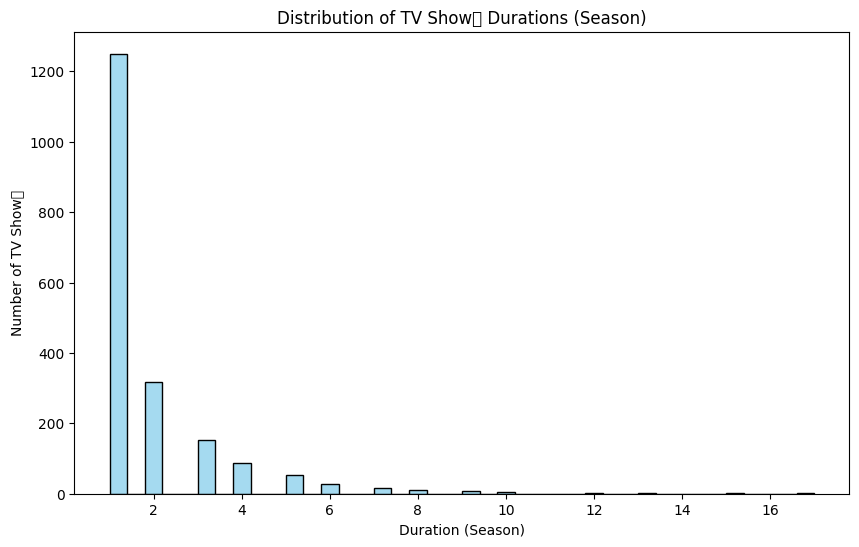

,count
duration,
1.0,1250
2.0,317
3.0,153
4.0,86
5.0,54
6.0,29
7.0,17
8.0,11
9.0,7


In [33]:
plt.figure(figsize=(10,6))

plt.title("Distribution of TV Show	 Durations (Season)")

sns.histplot(TV_Show_durations, bins=40, kde=False, color="skyblue")

plt.ylabel("Number of TV Show	")
plt.xlabel("Duration (Season)")
plt.show()

TV_Show_durations.value_counts()

10.Are there patterns or frequently occurring words in the descriptions of successful titles?

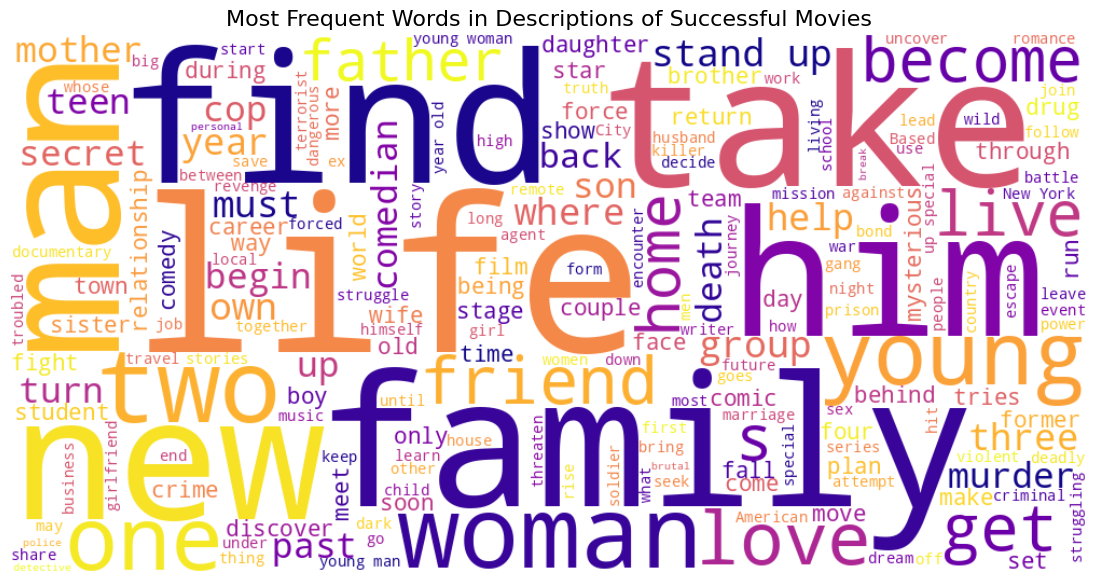

In [34]:
from wordcloud import WordCloud


successful = df_net[(df_net['type'] == 'Movie') & (df_net['rating'].isin(['TV-MA', 'R']))].copy()

text = " ".join(successful['description'])

custom_stopwords = set([
    'the', 'and', 'with', 'his', 'her', 'who', 'in', 'of', 'their', 'for', 'that', 'to', 'from',
    'he', 'she', 'a', 'an', 'on', 'at', 'as', 'is', 'it', 'by', 'about', 'this', 'its', 'was',
    'are', 'be', 'has', 'have', 'they', 'them', 'will', 'after', 'before', 'when', 'while', 'over',
    'into', 'out', 'just', 'your', 'can', 'all', 'but', 'if'
])

wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='plasma', stopwords=custom_stopwords).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Descriptions of Successful Movies", fontsize=16)
plt.show()


11.What is The Highest year you have added artwork?¶

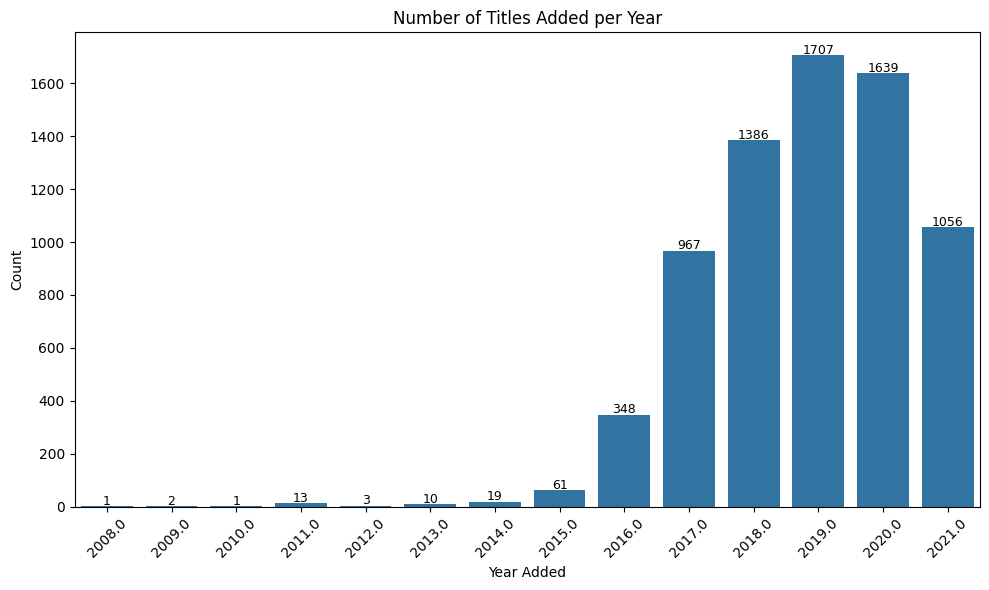

In [35]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='year', data=df_net, order=sorted(df_net['year'].unique()))
plt.title('Number of Titles Added per Year')
plt.xticks(rotation=45)
plt.xlabel('Year Added')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, f'{int(height)}',
            ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

12.What is The Highest month you have added artwork?¶

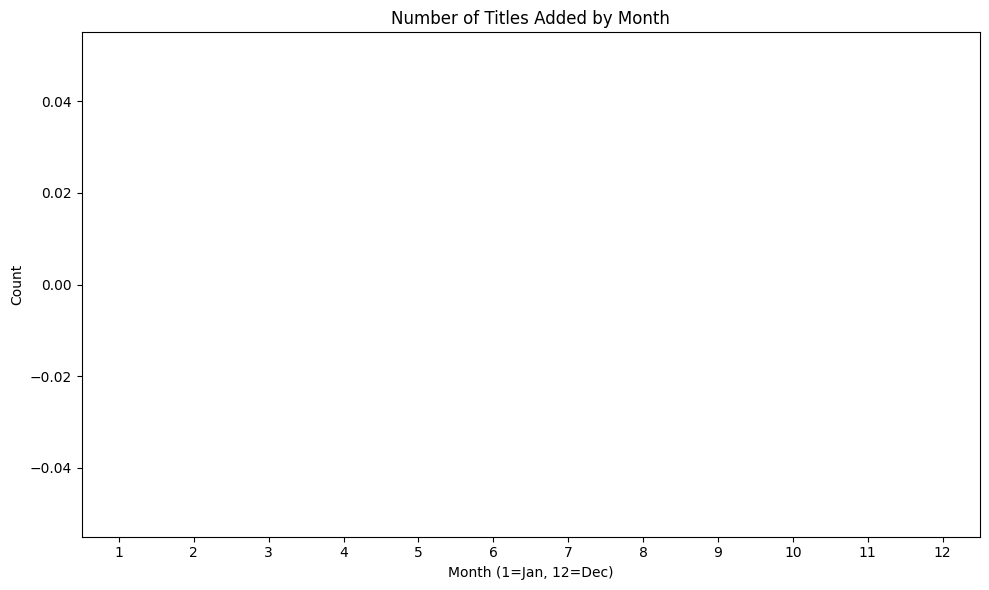

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='month', data=df_net, order=range(1, 13))
plt.title('Number of Titles Added by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, f'{int(height)}',
            ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

13.What is The Highest Day you have added artwork?

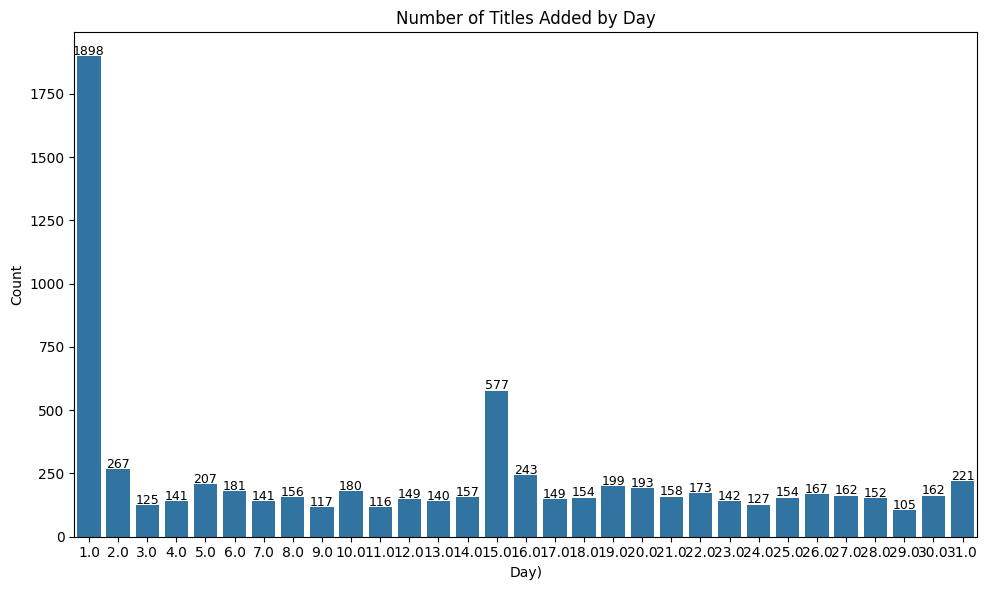

<Figure size 640x480 with 0 Axes>

In [37]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='day', data=df_net)
plt.title('Number of Titles Added by Day')
plt.xlabel('Day)')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, f'{int(height)}',
            ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

2.Bivariate Data Visualization¶

In [38]:
df_net.sample(10)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
7258,s7259,TV Show,La Viuda Negra,Alejandro Lozano,"Ana Serradilla, Julián Román, Ramiro Meneses, ...","Colombia, Mexico, United States",2016,TV-14,1 Season,"Crime TV Shows, International TV Shows, Spanis...","Beautiful and ruthless Griselda Blanco, known ...",15.0,1.0,2019.0
2808,s2809,TV Show,We Speak Dance,Not Available,Vandana Hart,United States,2018,TV-MA,1 Season,Docuseries,Trained dancer Vandana Hart travels the world ...,17.0,3.0,2020.0
1837,s1838,TV Show,Grand Army,Not Available,"Odessa A’zion, Odley Jean, Amir Bageria, Maliq...",United States,2020,TV-MA,1 Season,"TV Dramas, Teen TV Shows",Five students at the largest public high schoo...,16.0,10.0,2020.0
1900,s1901,Movie,Vampires vs. the Bronx,Oz Rodriguez,"Jaden Michael, Gerald W. Jones III, Gregory Di...",United States,2020,PG-13,86 min,"Comedies, Horror Movies",Three gutsy kids from a rapidly gentrifying Br...,2.0,10.0,2020.0
891,s892,Movie,Layer Cake,Matthew Vaughn,"Daniel Craig, Colm Meaney, Kenneth Cranham, Si...",United Kingdom,2004,R,105 min,"Independent Movies, International Movies, Thri...","A suave, steely-eyed London cocaine dealer's r...",13.0,5.0,2021.0
2600,s2601,TV Show,Good Witch,Not Available,"Catherine Bell, Bailee Madison, Rhys Matthew B...","United States, Canada",2019,TV-PG,5 Season,"TV Dramas, TV Sci-Fi & Fantasy","Raising her daughter in a small town, an encha...",30.0,4.0,2020.0
802,s803,Movie,Ninja Assassin,James McTeigue,"Rain, Naomie Harris, Ben Miles, Rick Yune, Shô...","Germany, United States, France",2009,R,99 min,Action & Adventure,A former assassin must protect himself and a E...,2.0,6.0,2021.0
3491,s3492,TV Show,Glitch,Not Available,"Patrick Brammall, Genevieve O'Reilly, Emma Boo...",Australia,2019,TV-MA,3 Season,"International TV Shows, TV Dramas, TV Horror",A police officer and a doctor face an emotiona...,25.0,9.0,2019.0
6370,s6371,Movie,Bratz: The Movie,Sean McNamara,"Logan Browning, Janel Parrish, Nathalia Ramos,...",United States,2007,PG,102 min,"Children & Family Movies, Comedies",When high school hierarchy divides four best f...,29.0,6.0,2020.0
274,s275,TV Show,Grace and Frankie,Not Available,"Jane Fonda, Lily Tomlin, Martin Sheen, Sam Wat...",United States,2021,TV-MA,7 Season,"TV Comedies, TV Dramas","They’re not friends, but when their husbands l...",13.0,8.0,2021.0


1.What are the most common content ratings for each type of content (movies and TV shows)?¶

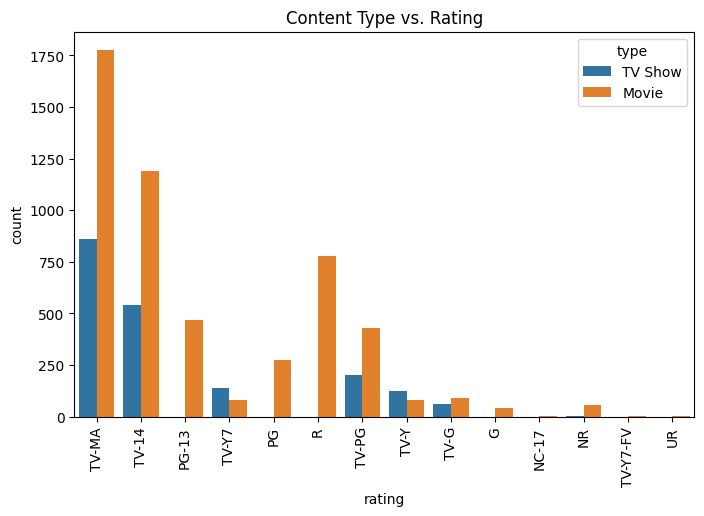

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', hue='type', data=df_net)
plt.title('Content Type vs. Rating')
plt.xticks(rotation=90)
plt.show()

2.Movies vs TV Shows Over the Years

<Figure size 800x400 with 0 Axes>

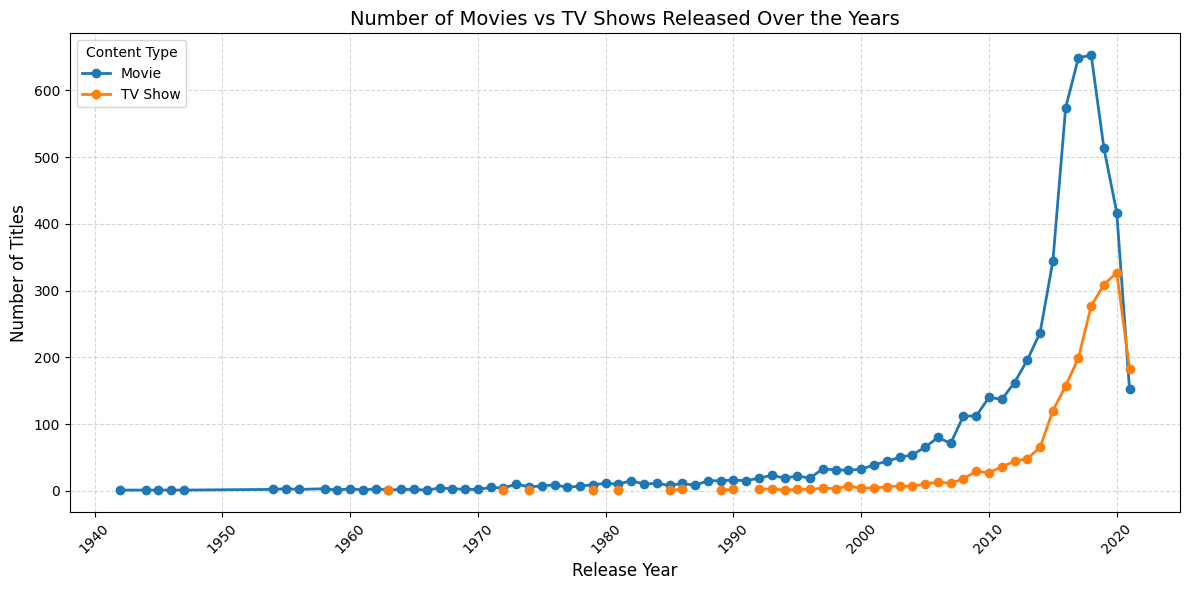

In [40]:
type_year = df_net.groupby(['release_year', 'type']).size().unstack().sort_index()

plt.figure(figsize=(8, 4))
type_year.plot(kind='line', marker='o', linewidth=2, figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])

plt.title('Number of Movies vs TV Shows Released Over the Years', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

3.Top 10 Countries vs. Type (Movie/TV Show)

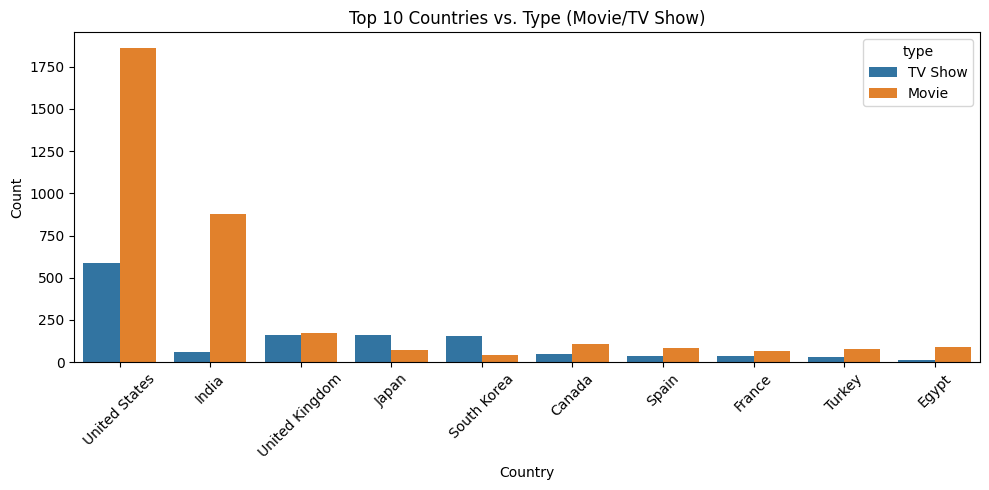

In [41]:
top_10_countries = df_net['country'].value_counts().head(10).index
df_top_countries = df_net[df_net['country'].isin(top_10_countries)]


plt.figure(figsize=(10, 5))
sns.countplot(x='country', hue='type', data=df_top_countries,order = top_10_countries)
plt.title('Top 10 Countries vs. Type (Movie/TV Show)')
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

4.Top 10 Directors vs. Type (Movie/TV Show)

/tmp/ipython-input-665046865.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_top_directors = df_net1[df_net['director'].isin(top_10_directors)]


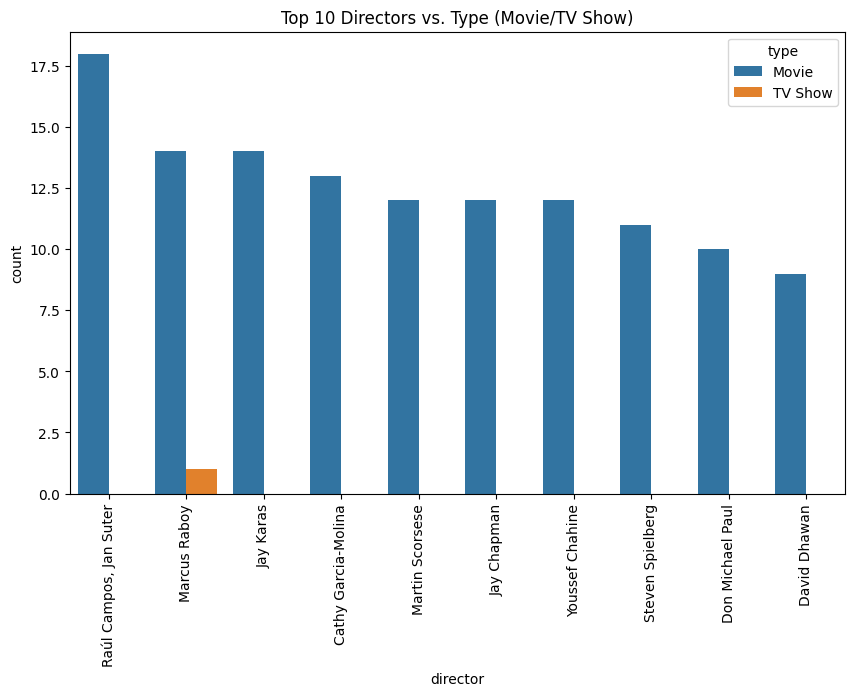

In [42]:
top_10_directors = df_net1['director'].value_counts().head(10).index
df_top_directors = df_net1[df_net['director'].isin(top_10_directors)]

plt.figure(figsize=(10, 6))
sns.countplot(x='director', hue='type', data=df_top_directors, order = top_10_directors )
plt.title('Top 10 Directors vs. Type (Movie/TV Show)')
plt.xticks(rotation=90)
plt.show()

5.Are TV shows added in different years compared to movies?¶

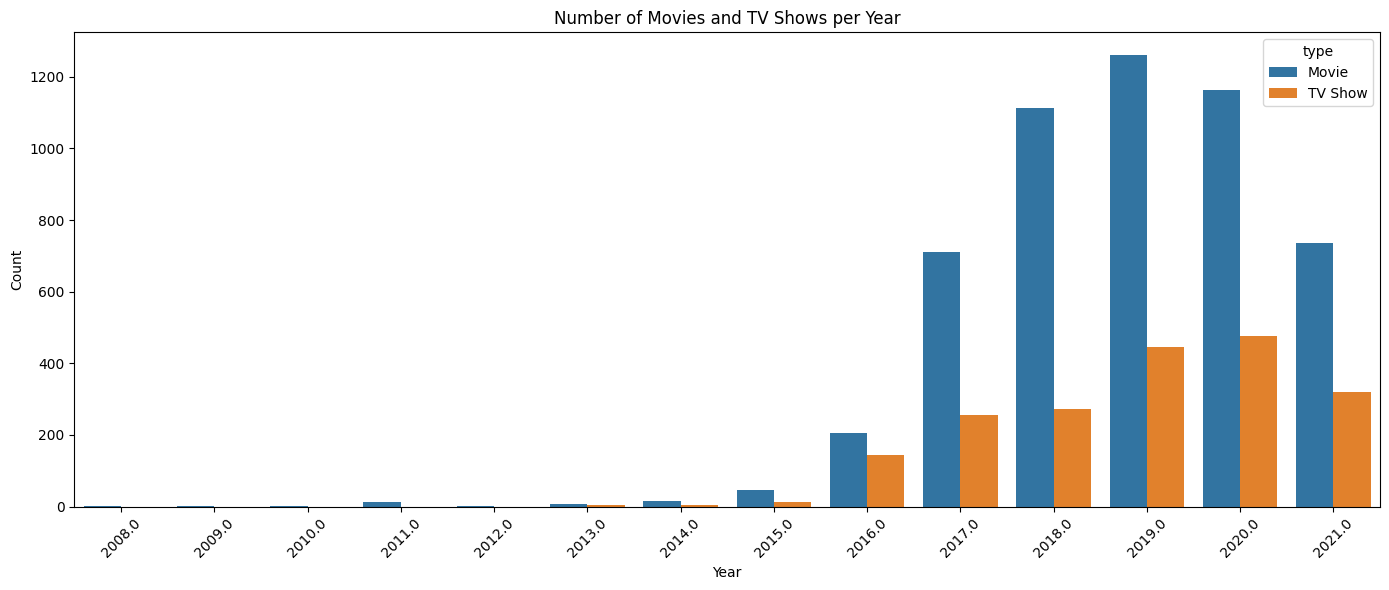

In [43]:
plt.figure(figsize=(14, 6))
sns.countplot(x='year', hue='type', data=df_net)
plt.title('Number of Movies and TV Shows per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6.Are TV shows added in different months compared to movies?¶

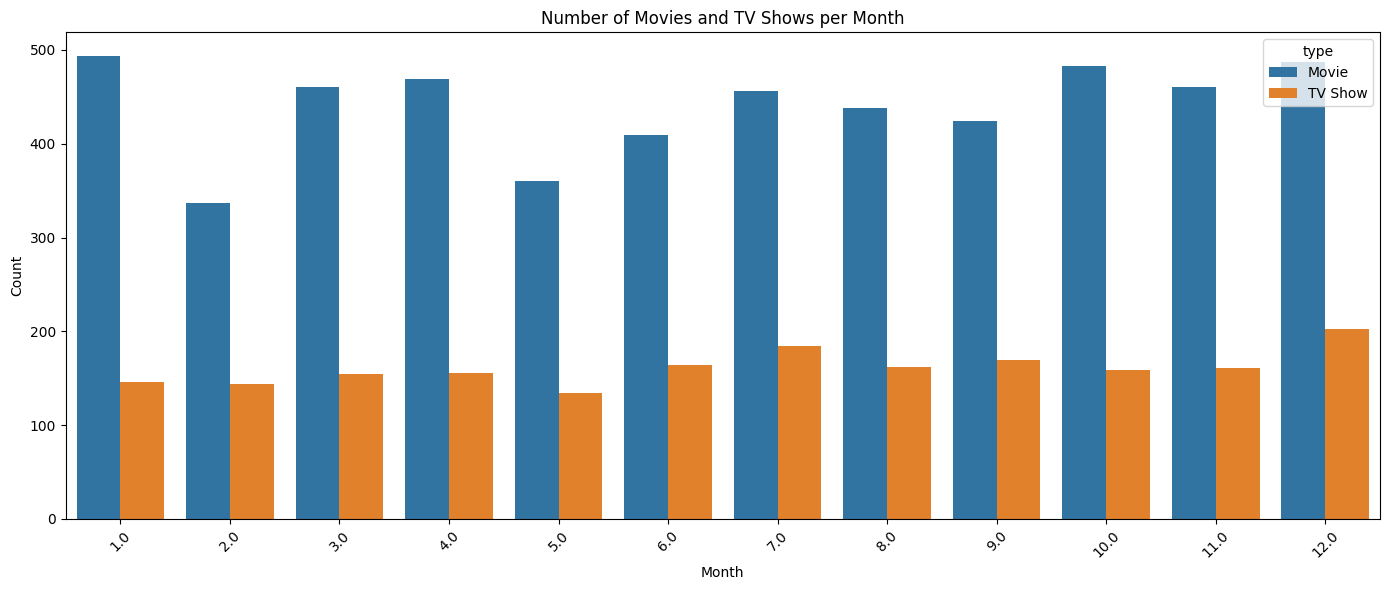

In [44]:
plt.figure(figsize=(14, 6))
sns.countplot(x='month', hue='type', data=df_net)
plt.title('Number of Movies and TV Shows per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

7.What are the most produced genres in recent years? And do they change over time?¶

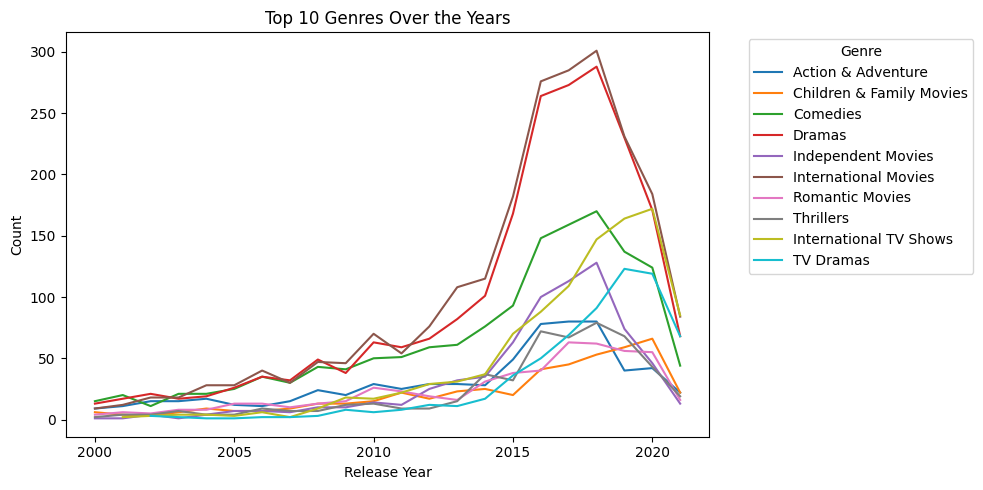

In [45]:
df_recent = df_net[df_net['release_year'] >= 2000].copy()

df_recent['listed_in'] = df_recent['listed_in'].str.split(', ')
df_exploded = df_recent.explode('listed_in')


genre_year_counts = df_exploded.groupby(['release_year', 'listed_in']).size().reset_index(name='count')


top_genres = genre_year_counts.groupby('listed_in')['count'].sum().sort_values(ascending=False).head(10).index
genre_year_top = genre_year_counts[genre_year_counts['listed_in'].isin(top_genres)]

plt.figure(figsize=(10, 5))
sns.lineplot(data=genre_year_top, x='release_year', y='count', hue='listed_in')
plt.title('Top 10 Genres Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

8.What is the relationship between a movie's duration and its genre (listed_in)?


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4020693640.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_movies['duration_min'] = df_movies['duration'].str.extract('(\d+)').astype(float)


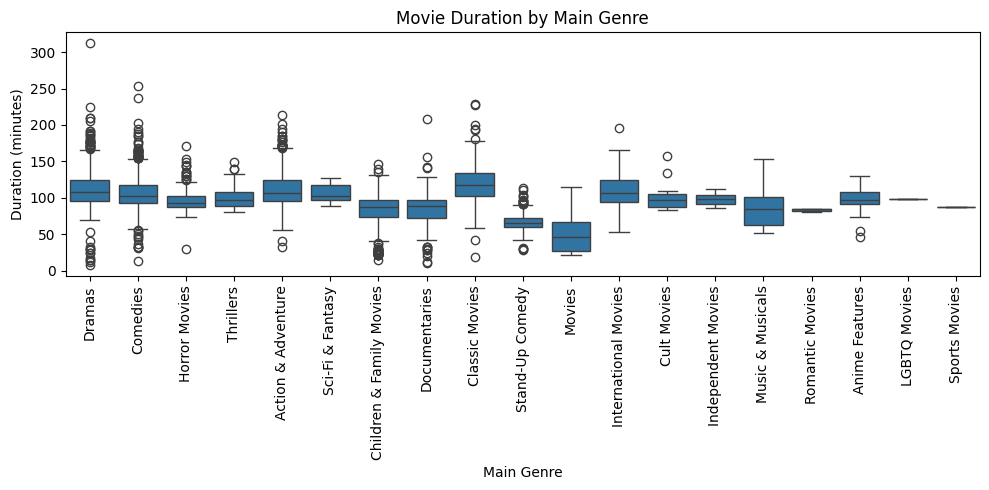

In [47]:
df_movies = df_net[df_net['type'] == 'Movie'].copy()
df_movies['duration_min'] = df_movies['duration'].str.extract('(\d+)').astype(float)
df_movies['main_genre'] = df_movies['listed_in'].str.split(',').str[0]


plt.figure(figsize=(10, 5))
sns.boxplot(data=df_movies, x='main_genre', y='duration_min')
plt.xticks(rotation=90)
plt.title('Movie Duration by Main Genre')
plt.xlabel('Main Genre')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()


9.Do children's ratings (such as TV-Y and TV-G) vary by country?

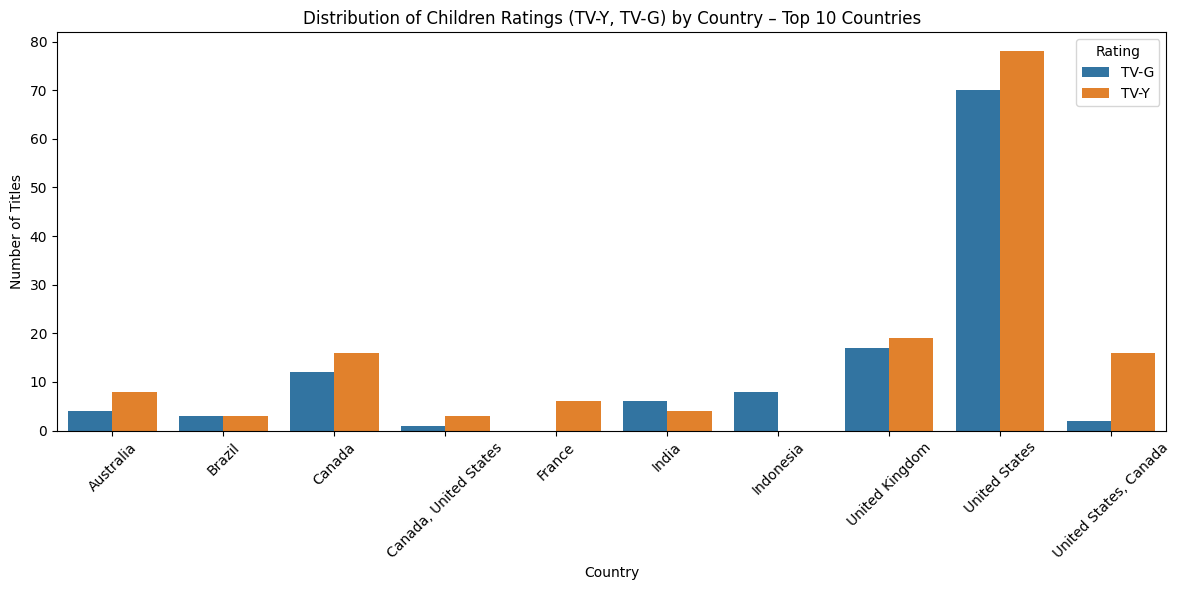

In [48]:
kids_ratings = df_net[df_net['rating'].isin(['TV-Y', 'TV-G'])]

top_countries = (
    kids_ratings['country'].value_counts()
    .head(10)
    .index.tolist()
)


top_rating_by_country = kids_ratings[kids_ratings['country'].isin(top_countries)]


top_grouped = top_rating_by_country.groupby(['country', 'rating']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_grouped, x='country', y='count', hue='rating')
plt.title('Distribution of Children Ratings (TV-Y, TV-G) by Country – Top 10 Countries')
plt.xticks(rotation=45)
plt.ylabel('Number of Titles')
plt.xlabel('Country')
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

10.Is there a change in the average number of seasons for TV shows over the years?

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1144219715.py:4: SyntaxWarning: invalid escape sequence '\d'
  tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)


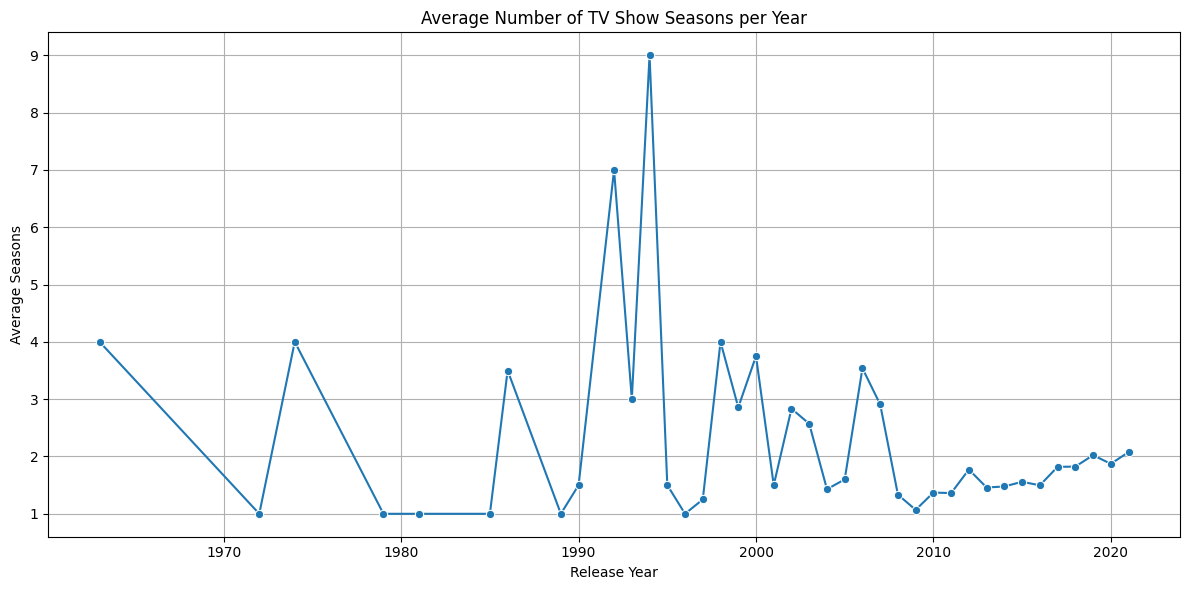

In [49]:
tv_shows = df_net[df_net['type'] == 'TV Show'].copy()


tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)


tv_shows = tv_shows.dropna(subset=['release_year', 'seasons'])


avg_seasons_per_year = (
    tv_shows.groupby('release_year')['seasons']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=avg_seasons_per_year, x='release_year', y='seasons', marker='o')
plt.title('Average Number of TV Show Seasons per Year')
plt.xlabel('Release Year')
plt.ylabel('Average Seasons')
plt.grid(True)
plt.tight_layout()
plt.show()

# ***3.Machine Learning***

In [50]:
df_net.sample(10)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
3003,s3004,Movie,Fortune Feimster: Sweet & Salty,Krysia Plonka,Fortune Feimster,United States,2020,TV-MA,61 min,Stand-Up Comedy,"Actor, comedian and writer Fortune Feimster ta...",21.0,1.0,2020.0
5013,s5014,Movie,Something Huge,Carlo Padial,"Berto Romero, Carolina Bang, Javier Botet, Car...",Spain,2017,TV-MA,87 min,"Comedies, Independent Movies, International Mo...","A director and a comedian want to shoot the ""c...",1.0,3.0,2018.0
1676,s1677,Movie,Hawaizaada,Vibhu Virender Puri,"Ayushmann Khurrana, Mithun Chakraborty, Pallav...",India,2015,TV-14,129 min,"Dramas, International Movies, Romantic Movies","In 1895 Mumbai, spirited Indian lad Shiv Talpa...",19.0,11.0,2020.0
4310,s4311,TV Show,Travelers,Not Available,"Eric McCormack, MacKenzie Porter, Nesta Cooper...","Canada, United States",2018,TV-MA,3 Season,"Crime TV Shows, International TV Shows, TV Dramas",A federal agent tracks four people who suddenl...,14.0,12.0,2018.0
7322,s7323,Movie,Lizzie Borden Took an Ax,Nick Gomez,"Christina Ricci, Clea DuVall, Gregg Henry, Ste...",United States,2014,TV-14,87 min,Thrillers,This made-for-TV drama chronicles the scandal ...,25.0,7.0,2016.0
5620,s5621,Movie,The Reconquest,Jonás Trueba,"Francesco Carril, Itsaso Arana, Candela Recio,...",Spain,2016,TV-MA,108 min,"Dramas, International Movies, Romantic Movies","Years after they were childhood sweethearts, M...",1.0,2.0,2017.0
5839,s5840,Movie,Sofía Niño de Rivera: Exposed,"Raúl Campos, Jan Suter",Sofía Niño de Rivera,Mexico,2016,TV-MA,80 min,Stand-Up Comedy,Self-deprecating comic Sofía Niño de Rivera pu...,24.0,6.0,2016.0
5892,s5893,Movie,Circle,"Aaron Hann, Mario Miscione","Julie Benz, Mercy Malick, Carter Jenkins, Moll...",United States,2015,TV-MA,86 min,"Dramas, Independent Movies, Sci-Fi & Fantasy",When a group of strangers is seized and awaits...,16.0,10.0,2015.0
1019,s1020,Movie,Lagaan,Ashutosh Gowariker,"Aamir Khan, Gracy Singh, Rachel Shelley, Paul ...","India, United Kingdom",2001,PG,224 min,"Dramas, International Movies, Music & Musicals","In 1890s India, an arrogant British commander ...",17.0,4.0,2021.0
7905,s7906,Movie,Running Out Of Time,Chris Stokes,"Tasha Smith, RonReaco Lee, Telma Hopkins, Sydn...",United States,2018,TV-14,88 min,Thrillers,Held hostage by men searching for a secret her...,1.0,8.0,2019.0


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score

In [52]:
df = df_net.copy()
df['text'] = df['title'] + ' ' + df['description'] + ' ' + df['listed_in']
df = df[['text','country','rating','release_year','type']]

In [53]:
df.head()

,text,country,rating,release_year,type
1,"Blood & Water After crossing paths at a party,...",South Africa,TV-MA,2021,TV Show
4,Kota Factory In a city of coaching centers kno...,India,TV-MA,2021,TV Show
7,"Sankofa On a photo shoot in Ghana, an American...","United States, Ghana, Burkina Faso, United Kin...",TV-MA,1993,Movie
8,The Great British Baking Show A talented batch...,United Kingdom,TV-14,2021,TV Show
9,The Starling A woman adjusting to life after a...,United States,PG-13,2021,Movie


In [54]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = vectorizer.fit_transform(df['text'])

In [55]:
ohe = OneHotEncoder()
other_features = ohe.fit_transform(df[['country', 'rating', 'release_year']])


X = hstack([tfidf_matrix, other_features])
y = df['type']

In [56]:
print(X.shape)
X_df = pd.DataFrame(X.toarray())
print(X_df.sample(10))

(7213, 872)
           0         1         2    3    4    5    6         7    8    9    \
3734  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
1565  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
4409  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
7109  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.573318  0.0  0.0   
4033  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
3541  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
4973  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
6011  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   
6105  0.274492  0.269401  0.447671  0.0  0.0  0.0  0.0  0.407681  0.0  0.0   
1685  0.000000  0.000000  0.000000  0.0  0.0  0.0  0.0  0.000000  0.0  0.0   

      ...  862  863  864  865  866  867  868  869  870  871  
3734  ...  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  
1565 

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [59]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

Accuracy: 0.9951489951489951
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1039
     TV Show       1.00      0.99      0.99       404

    accuracy                           1.00      1443
   macro avg       1.00      0.99      0.99      1443
weighted avg       1.00      1.00      1.00      1443



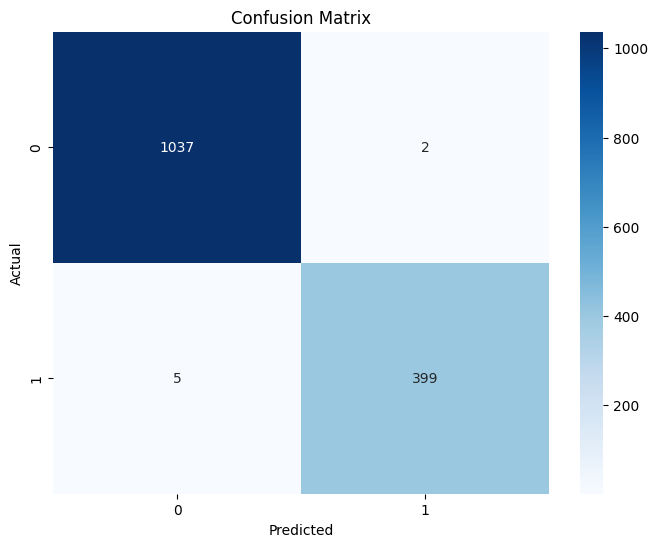

In [60]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()